In [1]:
import warnings

# 모든 경고 무시
warnings.filterwarnings("ignore")

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'   # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 깨짐 방지


=== 출산율과 상관관계 ===
출산율                    1.000000
혼인율(남성)                0.979684
혼인율(여성)                0.782962
비경제활동인구 (천명)           0.217939
실업률 (%)                0.060340
경제성장률                  0.050365
소비자심리지수                0.049386
실업자 (천명)              -0.012686
소비자물가지수(CPI)          -0.156309
국내총생산(GDP) 단위 : 10억   -0.164299
취업자 (천명)              -0.458987
경제활동인구 (천명)           -0.501383
고용률 (%)               -0.521917
경제활동참가율 (%)           -0.543816
Name: 출산율, dtype: float64

=== Bartlett Test: 출산율 vs 다른 변수들의 등분산 검정 ===
혼인율(남성): stat=37.385, p=0.0000
혼인율(여성): stat=19.483, p=0.0000
경제활동인구 (천명): stat=294.253, p=0.0000
취업자 (천명): stat=311.004, p=0.0000
실업자 (천명): stat=1.142, p=0.2852
비경제활동인구 (천명): stat=231.193, p=0.0000
경제활동참가율 (%): stat=306.467, p=0.0000
실업률 (%): stat=424.812, p=0.0000
고용률 (%): stat=296.886, p=0.0000
국내총생산(GDP) 단위 : 10억: stat=1732.916, p=0.0000
경제성장률: stat=737.458, p=0.0000
소비자심리지수: stat=180.970, p=0.0000
소비자물가지수(CPI): stat=155.902, p=0.0000


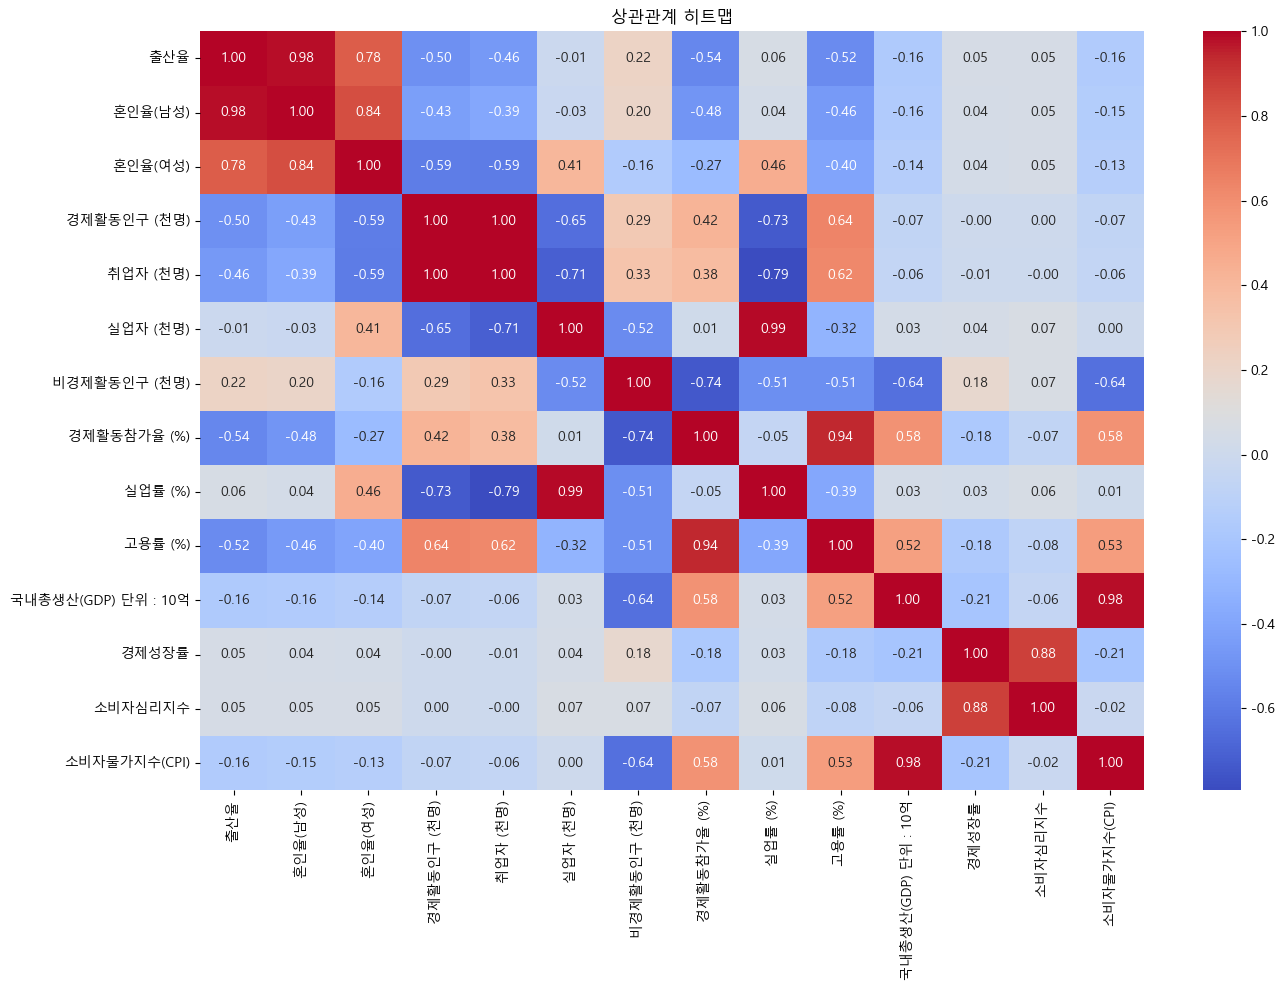


=== 출산율과 상관계수 TOP 5 ===
혼인율(남성)        0.979684
혼인율(여성)        0.782962
경제활동참가율 (%)    0.543816
고용률 (%)        0.521917
경제활동인구 (천명)    0.501383
Name: 출산율, dtype: float64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, bartlett
import seaborn as sns

# ================================
# 1. CSV 로드 (파일명 수정해서 사용)
# ================================
df = pd.read_csv(r"C:\Users\user\Downloads\dataframe.csv")

# ================================
# 2. 숫자형 변환 (천 단위 콤마 제거)
# ================================
cols_to_clean = [
    "경제활동인구 (천명)", "취업자 (천명)", "실업자 (천명)", 
    "비경제활동인구 (천명)", "국내총생산(GDP) 단위 : 10억",
]

for c in cols_to_clean:
    df[c] = df[c].astype(str).str.replace(",", "").astype(float)

# ================================
# 3. 필요한 분석용 컬럼 선택
# ================================
analysis_cols = [
    "출산율",
    "혼인율(남성)", "혼인율(여성)",
    "경제활동인구 (천명)", "취업자 (천명)", "실업자 (천명)",
    "비경제활동인구 (천명)",
    "경제활동참가율 (%)", "실업률 (%)", "고용률 (%)",
    "국내총생산(GDP) 단위 : 10억",
    "경제성장률", "소비자심리지수", "소비자물가지수(CPI)"
]

df_analysis = df[analysis_cols].dropna()

# ================================
# 4. 상관계수 테이블 생성
# ================================
corr_table = df_analysis.corr(method="pearson")
print("=== 출산율과 상관관계 ===")
print(corr_table["출산율"].sort_values(ascending=False))

# ================================
# 5. Bartlett 등분산 검정
# ================================
print("\n=== Bartlett Test: 출산율 vs 다른 변수들의 등분산 검정 ===")
for col in analysis_cols:
    if col == "출산율":
        continue
    try:
        stat, p = bartlett(df_analysis["출산율"], df_analysis[col])
        print(f"{col}: stat={stat:.3f}, p={p:.4f}")
    except:
        print(f"{col}: 계산 불가")

# ================================
# 6. Heatmap 시각화
# ================================
plt.figure(figsize=(14, 10))
sns.heatmap(corr_table, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("상관관계 히트맵")
plt.tight_layout()
plt.show()

# ================================
# 7. 출산율과 가장 강한 상관 변수 TOP 5
# ================================
top5 = corr_table["출산율"].abs().sort_values(ascending=False)[1:6]
print("\n=== 출산율과 상관계수 TOP 5 ===")
print(top5)

사용되는 컬럼: ['출산율', '혼인율(남성)', '혼인율(여성)', '경제활동인구 (천명)', '취업자 (천명)', '실업자 (천명)', '비경제활동인구 (천명)', '경제활동참가율 (%)', '실업률 (%)', '고용률 (%)', '국내총생산(GDP) 단위 : 10억', '경제성장률', '소비자심리지수', '소비자물가지수(CPI)']

=== 정상성 검정 (ADF) ===
출산율: 정상성 없음 (p=0.9345) → 차분 적용
혼인율(남성): 정상성 없음 (p=0.4058) → 차분 적용
혼인율(여성): 정상성 없음 (p=0.4283) → 차분 적용
경제활동인구 (천명): 정상성 없음 (p=0.2458) → 차분 적용
취업자 (천명): 정상성 없음 (p=0.2649) → 차분 적용
실업자 (천명): 정상성 없음 (p=0.6773) → 차분 적용
비경제활동인구 (천명): 정상성 없음 (p=0.9973) → 차분 적용
경제활동참가율 (%): 정상성 없음 (p=0.9917) → 차분 적용
실업률 (%): 정상성 없음 (p=0.7792) → 차분 적용
고용률 (%): 정상성 없음 (p=0.9921) → 차분 적용
국내총생산(GDP) 단위 : 10억: 정상성 없음 (p=0.9965) → 차분 적용
경제성장률: 정상성 없음 (p=0.3060) → 차분 적용
소비자심리지수: 정상성 없음 (p=0.5031) → 차분 적용
소비자물가지수(CPI): 정상성 없음 (p=0.9492) → 차분 적용

정상성 확보 후 컬럼: ['출산율', '혼인율(남성)', '혼인율(여성)', '경제활동인구 (천명)', '취업자 (천명)', '실업자 (천명)', '비경제활동인구 (천명)', '경제활동참가율 (%)', '실업률 (%)', '고용률 (%)', '국내총생산(GDP) 단위 : 10억', '경제성장률', '소비자심리지수', '소비자물가지수(CPI)']

=== 출산율 상관관계 ===
출산율                    1.000000
혼인율(남성)                0.95

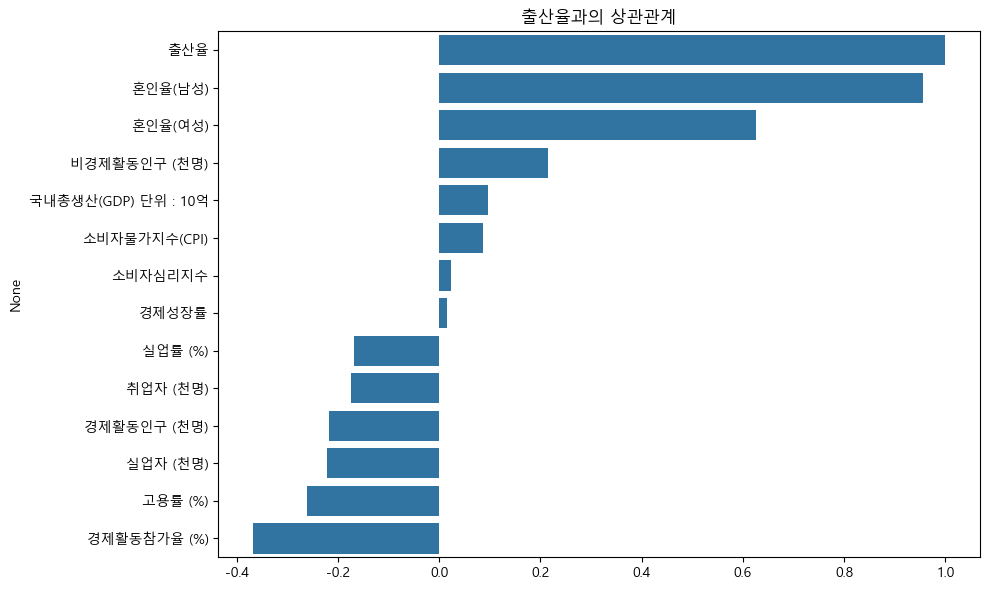


=== Granger Causality Test ===

[ 혼인율(남성) → 출산율 ]
lag=1 p-value = 0.0001

[ 혼인율(여성) → 출산율 ]
lag=1 p-value = 0.0000

[ 경제활동인구 (천명) → 출산율 ]
lag=1 p-value = 0.0000

[ 취업자 (천명) → 출산율 ]
lag=1 p-value = 0.0000

[ 실업자 (천명) → 출산율 ]
lag=1 p-value = 0.0000

[ 비경제활동인구 (천명) → 출산율 ]
lag=1 p-value = 0.0000

[ 경제활동참가율 (%) → 출산율 ]
lag=1 p-value = 0.0183

[ 실업률 (%) → 출산율 ]
lag=1 p-value = 0.0000

[ 고용률 (%) → 출산율 ]
lag=1 p-value = 0.2975

[ 국내총생산(GDP) 단위 : 10억 → 출산율 ]
lag=1 p-value = 0.0001

[ 경제성장률 → 출산율 ]
lag=1 p-value = 0.5459

[ 소비자심리지수 → 출산율 ]
lag=1 p-value = 0.3505

[ 소비자물가지수(CPI) → 출산율 ]
lag=1 p-value = 0.0003


In [4]:
# ==================================================
# 1) 데이터 로드 & 숫자 클린업 (안전한 방식)
# ==================================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(r"C:\Users\user\Downloads\dataframe.csv")

# ---- 숫자만 남기기 ----
def clean_str_to_num(val):
    if isinstance(val, str):
        val = re.sub(r"[^0-9.\-]", "", val)
    return val

df = df.map(clean_str_to_num)
df = df.apply(pd.to_numeric, errors="coerce")

# ---------------------------------------------
# 2) 필요한 컬럼만 선택 (중요)
# ---------------------------------------------
target = "출산율"

candidate_cols = [
    "출산율",
    "혼인율(남성)", "혼인율(여성)",
    "경제활동인구 (천명)", "취업자 (천명)", "실업자 (천명)",
    "비경제활동인구 (천명)",
    "경제활동참가율 (%)", "실업률 (%)", "고용률 (%)",
    "국내총생산(GDP) 단위 : 10억",
    "경제성장률", "소비자심리지수", "소비자물가지수(CPI)"
]

df = df[candidate_cols].dropna(how="all", axis=1)

print(f"사용되는 컬럼: {df.columns.tolist()}\n")

# ==================================================
# 3) 정상성 확보 (ADF + 차분) + 예외 처리
# ==================================================

def safe_adf(series):
    s = series.dropna()
    if len(s) < 5:
        return None, None  # insufficient data
    if s.max() == s.min():
        return None, None  # constant series
    try:
        result = adfuller(s)
        p = result[1]
        return result, p
    except:
        return None, None

df_stationary = pd.DataFrame()

print("=== 정상성 검정 (ADF) ===")
for col in df.columns:
    r, p = safe_adf(df[col])

    if p is None:
        print(f"{col}: 데이터 부족/상수 → 제거")
        continue

    if p < 0.05:
        print(f"{col}: 정상성 있음 (p={p:.4f}) → 원본 사용")
        df_stationary[col] = df[col]
    else:
        print(f"{col}: 정상성 없음 (p={p:.4f}) → 차분 적용")
        df_stationary[col] = df[col].diff()

df_stationary = df_stationary.dropna()

print("\n정상성 확보 후 컬럼:", df_stationary.columns.tolist())

# ==================================================
# 4) 표준화
# ==================================================
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_stationary),
    index=df_stationary.index,
    columns=df_stationary.columns
)

# ==================================================
# 5) 상관관계 분석
# ==================================================

corr = df_scaled.corr()[target].sort_values(ascending=False)
print("\n=== 출산율 상관관계 ===")
print(corr)

plt.figure(figsize=(10, 6))
sns.barplot(y=corr.index, x=corr.values)
plt.title("출산율과의 상관관계")
plt.tight_layout()
plt.show()

# ==================================================
# 6) Granger Causality Test
# ==================================================
print("\n=== Granger Causality Test ===")

maxlag = 2

for col in df_stationary.columns:
    if col == target:
        continue

    print(f"\n[ {col} → 출산율 ]")
    try:
        g = grangercausalitytests(
            df_stationary[[target, col]], 
            maxlag=maxlag, 
            verbose=False
        )
        p = g[1][0]["ssr_ftest"][1]
        print(f"lag=1 p-value = {p:.4f}")
    except Exception as e:
        print("테스트 불가:", e)

사용 컬럼: ['출산율', '혼인율(남성)', '혼인율(여성)']

=== ADF 정상성 검정 ===
출산율: 정상성 있음 (p=0.0000) → 원자료 사용
혼인율(남성): 정상성 있음 (p=0.0000) → 원자료 사용
혼인율(여성): 정상성 있음 (p=0.0000) → 원자료 사용

정상성 확보 후 index 범위: 2004 ~ 2024
정상성 확보 후 컬럼: ['출산율', '혼인율(남성)', '혼인율(여성)']

Rolling Window 구간들: [(2004, 2007), (2008, 2011), (2012, 2015), (2016, 2019), (2020, 2023)]

=== Rolling Window 결과표 ===
           corr_혼인율(남성)  corr_혼인율(여성)  p_혼인율(남성)  p_혼인율(여성)
window                                                     
2004~2007      0.985230      0.809339   0.153331   0.025929
2008~2011      0.983377      0.784779   0.210378   0.001952
2012~2015      0.982765      0.771708   0.655859   0.007880
2016~2019      0.978945      0.766761   0.611384   0.076435
2020~2023      0.970581      0.786996   0.782758   0.205219


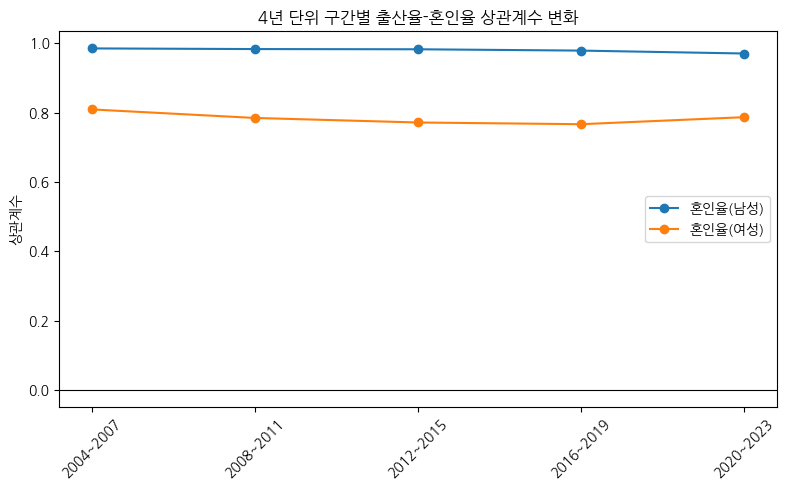

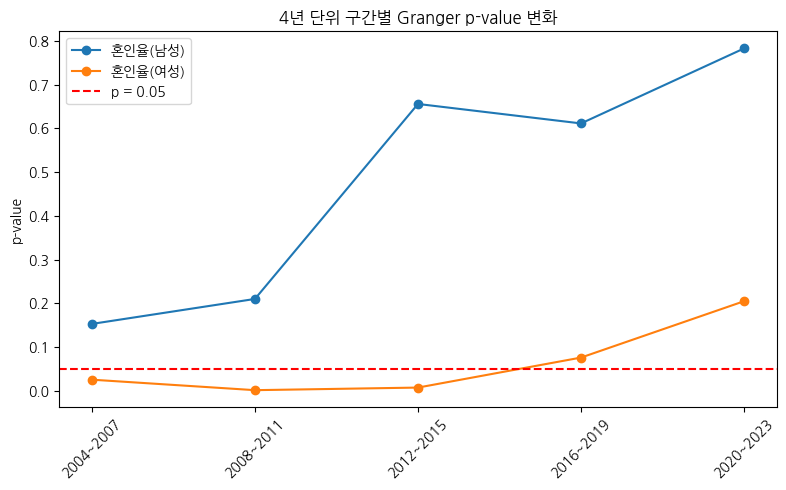

In [9]:
# ==================================================
# Rolling Window 기반 시점별 분석 (4년 단위, 혼인율만)
# ==================================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

plt.rc('font', family='NanumGothic')

# ---------------------------------------------------
# 1) Load & Cleaning
# ---------------------------------------------------
df = pd.read_csv(r"C:\Users\user\Downloads\dataframe.csv")

def clean_str_to_num(val):
    if isinstance(val, str):
        val = re.sub(r"[^0-9.\-]", "", val)
    return val

df = df.applymap(clean_str_to_num)
df = df.apply(pd.to_numeric, errors="coerce")

# ---------------------------------------------------
# 2) 연도를 기준으로 정렬
# ---------------------------------------------------
if "시점" not in df.columns:
    raise ValueError("dataframe.csv에 '시점' 컬럼이 없습니다!")
df = df.sort_values("시점").set_index("시점")

# ---------------------------------------------------
# 3) 컬럼 선택 (출산율 + 혼인율만)
# ---------------------------------------------------
target = "출산율"
candidate_cols = [
    "출산율",
    "혼인율(남성)",
    "혼인율(여성)"
]

df = df[candidate_cols].dropna(how="all", axis=1)

# 실제 존재하는 컬럼만 다시 한 번 필터 (혹시라도 누락된 경우 대비)
cols_exist = [c for c in candidate_cols if c in df.columns]
df = df[cols_exist]

print("사용 컬럼:", df.columns.tolist())

# ---------------------------------------------------
# 4) 정상성 확보 (ADF → 비정상은 차분)
# ---------------------------------------------------
from statsmodels.tsa.stattools import adfuller

def safe_adf(series):
    s = series.dropna()
    if len(s) < 5 or s.max() == s.min():
        return None, None
    try:
        result = adfuller(s)
        return result, result[1]  # result, p-value
    except:
        return None, None

df_stationary = pd.DataFrame()
print("\n=== ADF 정상성 검정 ===")
for col in df.columns:
    r, p = safe_adf(df[col])
    if p is None:
        print(f"{col}: 데이터 부족/상수 → 제외")
        continue
    if p < 0.05:
        print(f"{col}: 정상성 있음 (p={p:.4f}) → 원자료 사용")
        df_stationary[col] = df[col]
    else:
        print(f"{col}: 정상성 없음 (p={p:.4f}) → 1차 차분 사용")
        df_stationary[col] = df[col].diff()

df_stationary = df_stationary.dropna()
print("\n정상성 확보 후 index 범위:", df_stationary.index.min(), "~", df_stationary.index.max())
print("정상성 확보 후 컬럼:", df_stationary.columns.tolist())

# ---------------------------------------------------
# 5) 4년 단위 구간 생성
# ---------------------------------------------------
years = df_stationary.index.to_list()
start_year = years[0]
end_year = years[-1]

windows = []
y = start_year
while y + 3 <= end_year:
    windows.append((y, y + 3))
    y += 4

print("\nRolling Window 구간들:", windows)

# ---------------------------------------------------
# 6) 구간별 결과 저장용 리스트
# ---------------------------------------------------
results = []

for (start, end) in windows:
    df_win = df_stationary.loc[start:end]

    # 최소 3개 이상 연도 있어야 상관/Granger 조금이라도 의미 있음
    if df_win.shape[0] < 3:
        continue

    # 상관계수 (출산율 기준)
    corr = df_win.corr()[target]

    row = {
        "window": f"{start}~{end}",
        "corr_혼인율(남성)": np.nan,
        "corr_혼인율(여성)": np.nan,
        "p_혼인율(남성)": np.nan,
        "p_혼인율(여성)": np.nan,
    }

    # 상관계수 저장
    if "혼인율(남성)" in corr.index:
        row["corr_혼인율(남성)"] = corr["혼인율(남성)"]
    if "혼인율(여성)" in corr.index:
        row["corr_혼인율(여성)"] = corr["혼인율(여성)"]

    # Granger p-value (lag=1 기준)
    for col in ["혼인율(남성)", "혼인율(여성)"]:
        if col not in df_win.columns:
            continue
        try:
            g = grangercausalitytests(
                df_win[[target, col]],
                maxlag=2,
                verbose=False
            )
            # lag=1 결과 사용
            p_val = g[1][0]["ssr_ftest"][1]
            row[f"p_{col}"] = p_val
        except Exception as e:
            # 너무 짧은 구간이나 수치 문제 등은 NaN으로 둠
            row[f"p_{col}"] = np.nan

    results.append(row)

# ---------------------------------------------------
# 7) 결과 DataFrame으로 정리
# ---------------------------------------------------
if not results:
    print("\nRolling Window에서 유의미한 구간이 없습니다.")
else:
    res_df = pd.DataFrame(results)
    res_df = res_df.set_index("window")
    print("\n=== Rolling Window 결과표 ===")
    print(res_df)

    # ---------------------------------------------------
    # 8) 상관계수 Line Plot
    # ---------------------------------------------------
    plt.figure(figsize=(8, 5))
    if "corr_혼인율(남성)" in res_df.columns:
        plt.plot(res_df.index, res_df["corr_혼인율(남성)"],
                 marker="o", label="혼인율(남성)")
    if "corr_혼인율(여성)" in res_df.columns:
        plt.plot(res_df.index, res_df["corr_혼인율(여성)"],
                 marker="o", label="혼인율(여성)")
    
    plt.axhline(0, color="black", linewidth=0.8)
    plt.title("4년 단위 구간별 출산율-혼인율 상관계수 변화")
    plt.ylabel("상관계수")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------
    # 9) Granger p-value Line Plot
    # ---------------------------------------------------
    plt.figure(figsize=(8, 5))
    if "p_혼인율(남성)" in res_df.columns:
        plt.plot(res_df.index, res_df["p_혼인율(남성)"],
                 marker="o", label="혼인율(남성)")
    if "p_혼인율(여성)" in res_df.columns:
        plt.plot(res_df.index, res_df["p_혼인율(여성)"],
                 marker="o", label="혼인율(여성)")

    plt.axhline(0.05, color="red", linestyle="--", label="p = 0.05")
    plt.title("4년 단위 구간별 Granger p-value 변화")
    plt.ylabel("p-value")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [6]:
# ==================================================
# 구간별 상관계수 + Granger p-value 표
# ==================================================
import pandas as pd

tables = []

for w in windows:
    start, end = w
    df_win = df_stationary.loc[start:end]
    if df_win.shape[0] < 2:
        continue
    
    res = analyze_window(df_win, target)
    
    # p<0.05 변수만
    significant_vars = [k for k,v in res["granger"].items() if v is not None and v < 0.05]
    if not significant_vars:
        continue
    
    # 상관계수 + Granger p-value 합치기
    data = {
        "변수": significant_vars,
        "상관계수": [res["corr"][k] for k in significant_vars],
        "Granger p-value": [res["granger"][k] for k in significant_vars],
        "구간": f"{start}~{end}"
    }
    tables.append(pd.DataFrame(data))

# 모든 구간 합치기
if tables:
    final_table = pd.concat(tables, ignore_index=True)
    display(final_table)
else:
    print("유의한 Granger 인과 변수가 없습니다.")

,변수,상관계수,Granger p-value,구간
0,혼인율(여성),0.787183,0.002647,2008~2011
1,경제활동인구 (천명),-0.631323,0.001946,2008~2011
2,취업자 (천명),-0.611411,0.000849,2008~2011
3,실업자 (천명),0.259954,0.000055,2008~2011
4,실업률 (%),0.326778,0.000034,2008~2011
5,혼인율(여성),0.771708,0.007880,2012~2015
6,경제활동인구 (천명),-0.545853,0.029740,2012~2015
7,취업자 (천명),-0.508999,0.022812,2012~2015
8,실업자 (천명),-0.008135,0.009129,2012~2015
9,실업률 (%),0.089443,0.007687,2012~2015


In [10]:
# ==================================================
# 구간별 상관계수 + Granger p-value 표 (혼인율만)
# - 앞에서 results / res_df까지 만든 상태라고 가정
# ==================================================
import pandas as pd

if not results:
    print("Rolling Window 결과가 없습니다.")
else:
    rows = []

    for window, row in res_df.iterrows():
        # (변수 이름, 상관계수 컬럼, p-value 컬럼)
        for var_name, corr_col, p_col in [
            ("혼인율(남성)", "corr_혼인율(남성)", "p_혼인율(남성)"),
            ("혼인율(여성)", "corr_혼인율(여성)", "p_혼인율(여성)"),
        ]:
            if corr_col not in res_df.columns or p_col not in res_df.columns:
                continue

            corr_val = row[corr_col]
            p_val = row[p_col]

            # p-value 없으면 스킵
            if pd.isna(p_val):
                continue

            # 🔸 p<0.05인 것만 보고 싶으면 이 조건 유지
            if p_val >= 0.05:
                continue

            rows.append({
                "구간": window,
                "변수": var_name,
                "상관계수": corr_val,
                "Granger p-value": p_val
            })

    if rows:
        final_table = pd.DataFrame(rows)
        display(final_table)
    else:
        print("p < 0.05를 만족하는 구간/변수가 없습니다.")


,구간,변수,상관계수,Granger p-value
0,2004~2007,혼인율(여성),0.809339,0.025929
1,2008~2011,혼인율(여성),0.784779,0.001952
2,2012~2015,혼인율(여성),0.771708,0.007880


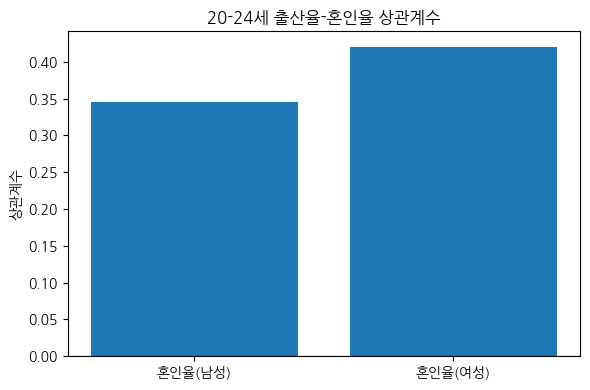

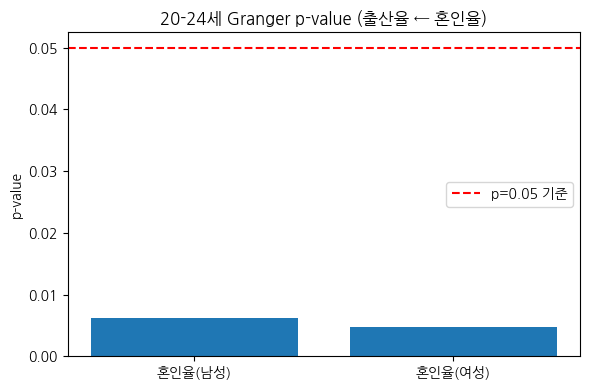

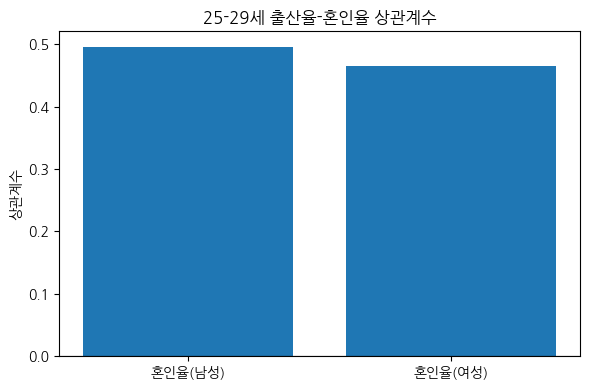

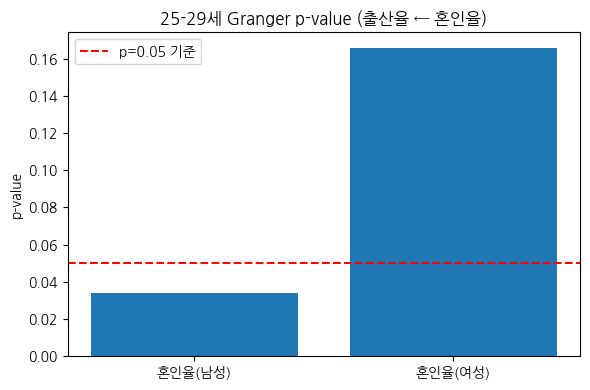

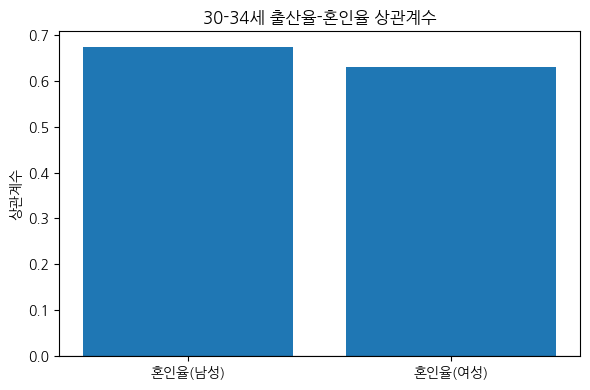

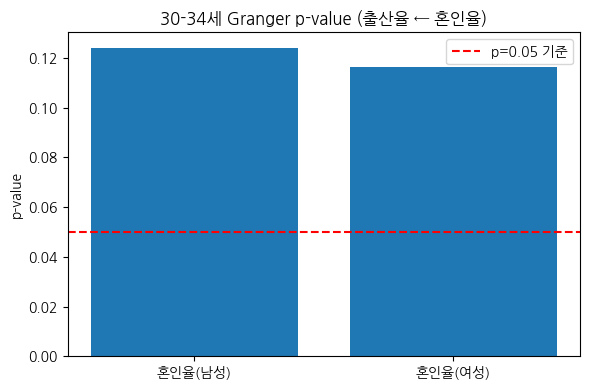

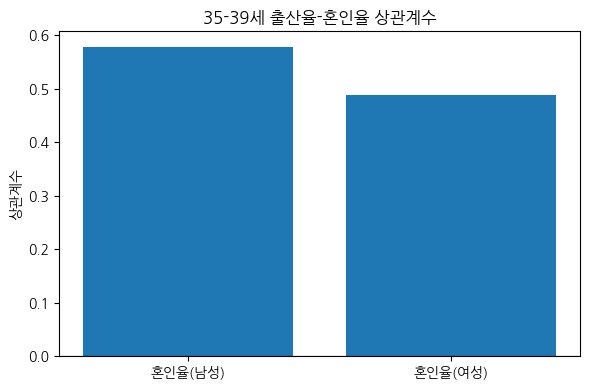

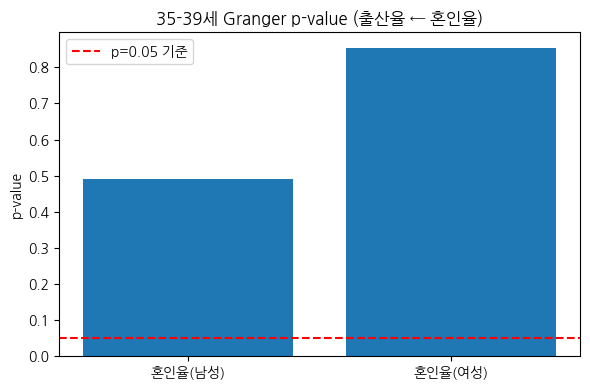

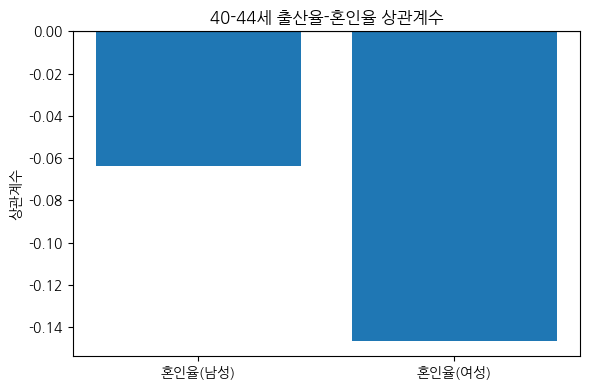

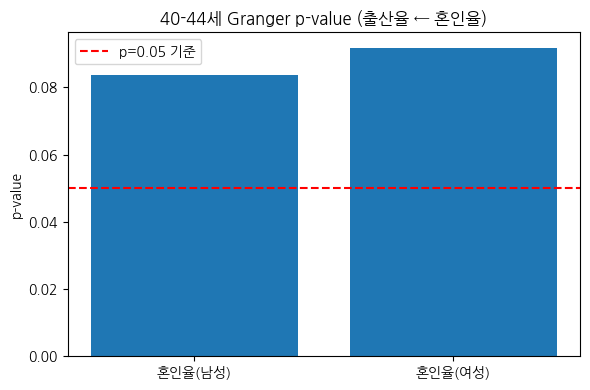

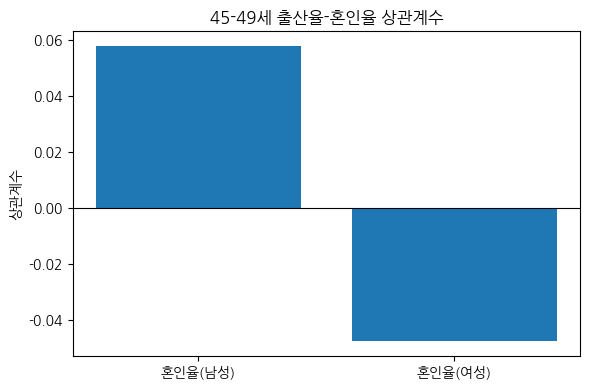

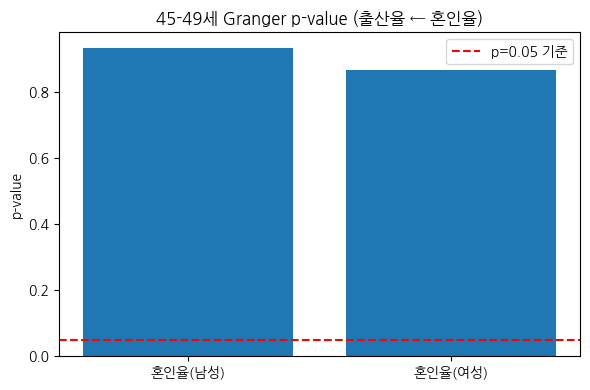

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

plt.rc('font', family='NanumGothic')

# 1) CSV 로드
df = pd.read_csv(r"C:\Users\user\Downloads\dataframe.csv")

# 2) Unnamed 컬럼 제거
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# 3) 숫자형 컬럼 처리
num_cols = df.columns.drop(['시점', '나이'])
for col in num_cols:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', ''),
        errors='coerce'
    )

# 4) 시점 기준 정렬 (시계열 필수)
df = df.sort_values(['나이', '시점'])

# 5) 분석 변수: 출산율 + 혼인율만
target = '출산율'
marriage_cols = ['혼인율(남성)', '혼인율(여성)']
age_groups = ['20-24세','25-29세','30-34세','35-39세','40-44세','45-49세']

# ADF + 차분 함수
def make_stationary(df_sub: pd.DataFrame) -> pd.DataFrame:
    df_stat = pd.DataFrame(index=df_sub.index)
    for c in df_sub.columns:
        s = df_sub[c].dropna()
        if len(s) < 5 or s.max() == s.min():
            # 너무 짧거나 상수면 제외
            continue
        try:
            pval = adfuller(s)[1]
        except:
            continue

        if pval < 0.05:
            df_stat[c] = df_sub[c]          # 정상 → 원자료
        else:
            df_stat[c] = df_sub[c].diff()   # 비정상 → 1차 차분
    return df_stat.dropna()

for age in age_groups:
    # 해당 연령대 데이터 추출
    df_age = df[df['나이'] == age].sort_values('시점')
    use_cols = [c for c in [target] + marriage_cols if c in df_age.columns]
    df_age = df_age[use_cols].copy()

    # 데이터 부족 시 패스
    if df_age.shape[0] < 5:
        print(f"{age}: 데이터 부족, 건너뜀")
        continue

    # 결측치 처리 (단순 평균 대체)
    df_age = df_age.fillna(df_age.mean())

    # 정상성 확보
    df_age_stat = make_stationary(df_age)
    if df_age_stat.shape[0] < 5 or target not in df_age_stat.columns:
        print(f"{age}: 정상성 확보 후 데이터 부족/출산율 누락, 건너뜀")
        continue

    # -------------------------
    # 상관계수 (출산율 vs 혼인율)
    # -------------------------
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df_age_stat),
        columns=df_age_stat.columns,
        index=df_age_stat.index
    )

    corr = df_scaled.corr()[target].drop(target)

    # -------------------------
    # Granger p-value
    # -------------------------
    granger_pvals = {}
    for col in marriage_cols:
        if col not in df_age_stat.columns:
            continue
        try:
            g = grangercausalitytests(
                df_age_stat[[target, col]],
                maxlag=2,
                verbose=False
            )
            pval = g[1][0]['ssr_ftest'][1]   # lag=1 기준
            granger_pvals[col] = pval
        except Exception as e:
            # print(f"{age} - {col}: Granger 실패 ({e})")
            continue

    if not granger_pvals:
        print(f"{age}: 유의한 Granger 결과 없음(혼인율)")
        continue

    # -------------------------
    # (그래프 1) 상관계수 Bar Plot
    # -------------------------
    corr_vals = {k: corr[k] for k in granger_pvals.keys() if k in corr.index}

    plt.figure(figsize=(6,4))
    plt.bar(corr_vals.keys(), corr_vals.values())
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title(f"{age} 출산율-혼인율 상관계수")
    plt.ylabel("상관계수")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # -------------------------
    # (그래프 2) Granger p-value Bar Plot
    # -------------------------
    plt.figure(figsize=(6,4))
    plt.bar(granger_pvals.keys(), granger_pvals.values())
    plt.axhline(0.05, color='red', linestyle='--', label='p=0.05 기준')
    plt.title(f"{age} Granger p-value (출산율 ← 혼인율)")
    plt.ylabel("p-value")
    plt.xticks(rotation=0)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import grangercausalitytests

# 분석 변수
target = '출산율'
other_vars = [
    '혼인율(남성)', '혼인율(여성)', '경제활동인구 (천명)', '취업자 (천명)',
    '실업자 (천명)', '비경제활동인구 (천명)', '경제활동참가율 (%)', '실업률 (%)', '고용률 (%)'
]

age_groups = ['20-24세','25-29세','30-34세','35-39세','40-44세','45-49세']

# 결과를 담을 리스트
all_results = []

for age in age_groups:
    df_age = df[df['나이'] == age][[target] + other_vars].copy()
    
    # 결측치 처리
    df_age = df_age.fillna(df_age.mean())
    
    # 데이터 부족하면 건너뜀
    if df_age.shape[0] < 2:
        print(f"{age}: 데이터 부족, 건너뜀")
        continue
    
    # 스케일링
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_age), columns=df_age.columns, index=df_age.index)
    
    # 상관계수 계산
    corr = df_scaled.corr()[target].drop(target)
    
    # Granger 검정
    granger_pvals = {}
    for col in other_vars:
        try:
            g = grangercausalitytests(df_age[[target, col]], maxlag=2, verbose=False)
            pval = g[1][0]['ssr_ftest'][1]
            if pval < 0.05:
                granger_pvals[col] = pval
        except:
            continue
    
    # 표 형태로 저장
    for col, pval in granger_pvals.items():
        all_results.append({
            '연령대': age,
            '변수': col,
            '상관계수': corr[col],
            'Granger p-value': pval
        })

# DataFrame으로 변환
results_df = pd.DataFrame(all_results)

# 연령대, 상관계수 기준 정렬
results_df = results_df.sort_values(['연령대','상관계수'], ascending=[True, False])

# 출력
print(results_df)

      연령대            변수      상관계수  Granger p-value
1  20-24세       혼인율(여성)  0.974856         0.008338
0  20-24세       혼인율(남성)  0.966935         0.049469
2  25-29세       혼인율(남성)  0.989287         0.035032
4  30-34세  비경제활동인구 (천명)  0.617749         0.006392
3  30-34세       혼인율(여성)  0.333505         0.022493
6  30-34세       고용률 (%) -0.679269         0.009541
5  30-34세   경제활동참가율 (%) -0.681948         0.009006
7  40-44세  비경제활동인구 (천명) -0.745847         0.042148


In [14]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import grangercausalitytests

# 분석 변수
target = '출산율'
other_vars = [
    '혼인율(남성)', '혼인율(여성)', '경제활동인구 (천명)', '취업자 (천명)',
    '실업자 (천명)', '비경제활동인구 (천명)', '경제활동참가율 (%)', '실업률 (%)', '고용률 (%)'
]

age_groups = ['20-24세','25-29세','30-34세','35-39세','40-44세','45-49세']

all_results = []   # 전체 변수 결과 저장 리스트

# ---------------------------------------------------------------------
# 1) 연령대별 전체 변수 분석 (팀원 코드와 동일)
# ---------------------------------------------------------------------
for age in age_groups:
    df_age = df[df['나이'] == age][[target] + other_vars].copy()
    
    # 결측치 처리
    df_age = df_age.fillna(df_age.mean())
    
    # 데이터 부족하면 건너뜀
    if df_age.shape[0] < 2:
        print(f"{age}: 데이터 부족, 건너뜀")
        continue
    
    # 스케일링
    scaler = StandardScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df_age),
        columns=df_age.columns,
        index=df_age.index
    )
    
    # 상관계수 계산
    corr = df_scaled.corr()[target].drop(target)
    
    # Granger 검정
    granger_pvals = {}
    for col in other_vars:
        try:
            g = grangercausalitytests(df_age[[target, col]], maxlag=2, verbose=False)
            pval = g[1][0]['ssr_ftest'][1]
            if pval < 0.05:  # 유의한 변수만
                granger_pvals[col] = pval
        except:
            continue
    
    # 결과 저장
    for col, pval in granger_pvals.items():
        all_results.append({
            '연령대': age,
            '변수': col,
            '상관계수': corr[col],
            'Granger p-value': pval
        })

# ---------------------------------------------------------------------
# 2) DataFrame으로 변환 → 전체 결과표
# ---------------------------------------------------------------------
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(['연령대', '상관계수'], ascending=[True, False])

print("\n===== 전체 변수 결과표 =====")
print(results_df)

# ---------------------------------------------------------------------
# 3) 혼인율만 따로 뽑아서 정리 (발표용)
# ---------------------------------------------------------------------
marriage_only = results_df[
    results_df['변수'].isin(['혼인율(남성)', '혼인율(여성)'])
].copy()

marriage_only = marriage_only.sort_values(
    ['연령대', '상관계수'],
    ascending=[True, False]
)

print("\n===== 혼인율만 정리한 결과표 =====")
print(marriage_only)



===== 전체 변수 결과표 =====
      연령대            변수      상관계수  Granger p-value
1  20-24세       혼인율(여성)  0.974856         0.008338
0  20-24세       혼인율(남성)  0.966935         0.049469
2  25-29세       혼인율(남성)  0.989287         0.035032
4  30-34세  비경제활동인구 (천명)  0.617749         0.006392
3  30-34세       혼인율(여성)  0.333505         0.022493
6  30-34세       고용률 (%) -0.679269         0.009541
5  30-34세   경제활동참가율 (%) -0.681948         0.009006
7  40-44세  비경제활동인구 (천명) -0.745847         0.042148

===== 혼인율만 정리한 결과표 =====
      연령대       변수      상관계수  Granger p-value
1  20-24세  혼인율(여성)  0.974856         0.008338
0  20-24세  혼인율(남성)  0.966935         0.049469
2  25-29세  혼인율(남성)  0.989287         0.035032
3  30-34세  혼인율(여성)  0.333505         0.022493


In [15]:
import statsmodels.api as sm

X = df_scaled[["혼인율(남성)", "혼인율(여성)"]]
y = df_scaled["출산율"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    출산율   R-squared:                       0.225
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     2.617
Date:                Wed, 10 Dec 2025   Prob (F-statistic):              0.101
Time:                        10:44:17   Log-Likelihood:                -27.117
No. Observations:                  21   AIC:                             60.23
Df Residuals:                      18   BIC:                             63.37
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.138e-15      0.207  -5.49e-15      1.0